# Wasserstein--Procrustes Rigid Alignment

This notebook generates `fig:wasserstein-procrustes-rigid-motion`. The figure illustrates a quotient version of the quadratic Wasserstein distance in which rigid motions, here orientation-preserving rotations and translations, are optimized out. For two empirical measures supported on point clouds, the alternating scheme first solves an optimal transport assignment for the current pose and then solves the weighted orthogonal Procrustes problem in closed form. The exported panels show selected damped display iterates, after updates 1, 2, 3, 5, and 10, on a bunny silhouette sampled by farthest-point sampling; the damping is only used to make the visual progression readable.

Mathematically, for a fixed coupling $P$, the rigid step minimizes
$$\min_{R\in \mathrm{SO}(2),\,t\in\mathbb R^2}\sum_{i,j}P_{ij}\|R x_i+t-y_j\|^2,$$
which is the classical Procrustes update obtained from a singular value decomposition of the weighted cross-covariance.


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from PIL import Image
from scipy.optimize import linear_sum_assignment

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    GRAY,
    DIRAC_MARKER_SIZE,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "wasserstein-procrustes-rigid-motion"
OUT = figure_dir(NAME)
THUMB = FIGROOT / "thumbnails" / f"{NAME}.png"
THUMB.parent.mkdir(parents=True, exist_ok=True)
ASSET = FIGROOT / "assets" / "bunny.png"
rng = np.random.default_rng(2028)

## Farthest-point sampling of the silhouette

The silhouette is converted into a binary mask, then thinned to a nearly uniform point cloud by farthest-point sampling.  This keeps the geometry recognizable while making the transport assignment small enough to be solved exactly.

In [2]:
def load_bunny_candidates(max_candidates=9000):
    img = Image.open(ASSET).convert("L")
    arr = np.asarray(img)
    mask = arr < 128
    yy, xx = np.nonzero(mask)
    pts = np.column_stack([xx, -yy]).astype(float)
    pts -= pts.mean(axis=0, keepdims=True)
    pts /= np.max(np.linalg.norm(pts, axis=1))
    # Keep a random pool before FPS to make the quadratic memory footprint small.
    if len(pts) > max_candidates:
        idx = rng.choice(len(pts), size=max_candidates, replace=False)
        pts = pts[idx]
    return pts


def farthest_point_sample(points, n, start=None):
    points = np.asarray(points)
    if start is None:
        start = int(np.argmin(np.sum((points - points.mean(axis=0)) ** 2, axis=1)))
    chosen = [start]
    dist2 = np.sum((points - points[start]) ** 2, axis=1)
    for _ in range(1, n):
        idx = int(np.argmax(dist2))
        chosen.append(idx)
        dist2 = np.minimum(dist2, np.sum((points - points[idx]) ** 2, axis=1))
    return points[np.asarray(chosen)]


def rotate(points, angle):
    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c, -s], [s, c]])
    return points @ R.T

candidates = load_bunny_candidates()
X0 = farthest_point_sample(candidates, 170)
X0 -= X0.mean(axis=0, keepdims=True)
# Slight anisotropic scaling makes the bunny occupy the panel better.
X0[:, 1] *= 1.05
X0 /= np.max(np.linalg.norm(X0, axis=1))

true_angle = 0.55
true_shift = np.array([1.70, -0.42])
Y = rotate(X0, true_angle) + true_shift

## Alternating transport and rigid Procrustes updates

For the current pose, the OT step is a uniform assignment. Given this assignment, the rigid update minimizes the matched squared error exactly by the orthogonal Procrustes formula. The stored state with index $k$ is the displayed pose after $k$ damped Procrustes updates. This makes the panels labelled 1, 2, 3, 5, and 10 genuine algorithm iterates while still slowing the displayed motion enough to reveal the registration path.


In [5]:
def assignment_pairs(X, Y):
    C = np.sum((X[:, None, :] - Y[None, :, :]) ** 2, axis=2)
    row, col = linear_sum_assignment(C)
    inv = np.empty(len(row), dtype=int)
    inv[row] = col
    return inv, C[row, col].mean()


def rigid_procrustes(source, target):
    """Return R,t minimizing sum_i |source_i R^T + t - target_i|^2."""
    xbar = source.mean(axis=0)
    ybar = target.mean(axis=0)
    Xc = source - xbar
    Yc = target - ybar
    H = Xc.T @ Yc
    U, _, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T
    t = ybar - xbar @ R.T
    return R, t


def iterate_alignment(X0, Y, n_iter=10, damping=0.30):
    """Return displayed poses after each damped Procrustes update."""
    Xcur = X0.copy()
    states = {}
    for k in range(1, n_iter + 1):
        match, _ = assignment_pairs(Xcur, Y)
        R, t = rigid_procrustes(X0, Y[match])
        Xfull = X0 @ R.T + t
        Xcur = (1 - damping) * Xcur + damping * Xfull
        match_after, energy_after = assignment_pairs(Xcur, Y)
        states[k] = (Xcur.copy(), match_after.copy(), float(energy_after))
    return states

selected_iters = [1, 2, 3, 5, 10]
states = iterate_alignment(X0, Y, n_iter=max(selected_iters), damping=0.30)
energies = [states[k][2] for k in selected_iters]
print("selected mean matched squared costs:", dict(zip(selected_iters, [round(e, 5) for e in energies])))


selected mean matched squared costs: {1: 1.53134, 2: 0.76303, 3: 0.38535, 5: 0.10663, 10: 0.01266}


## Exported panels

Each panel shows the fixed target in black and the current registered source in a red-to-blue time color. A few faint transport segments are drawn from the current source position to its matched target atoms for the selected iterations $1,2,3,5,10$.

In [7]:
def draw_iteration_panel(iteration, X, match, energy, filename):
    color = interp_color(iteration / max(selected_iters), RED, BLUE)
    pts = np.vstack([X, Y])
    xlim, ylim = padded_limits(pts, pad=0.075)
    fig, ax = plt.subplots(figsize=(1.72, 1.72))

    # Draw a deterministic subset of assignment segments for legibility.
    idx = np.linspace(0, len(X) - 1, 34, dtype=int)
    segments = [[X[i], Y[match[i]]] for i in idx]
    lc = LineCollection(segments, colors=[(*color, 0.20)], linewidths=0.36, zorder=1)
    ax.add_collection(lc)

    ax.scatter(Y[:, 0], Y[:, 1], s=DIRAC_MARKER_SIZE * 0.48, color="#151515", edgecolor="none", zorder=2)
    ax.scatter(X[:, 0], X[:, 1], s=DIRAC_MARKER_SIZE * 0.55, color=color, edgecolor="none", zorder=3)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, OUT / filename, pad_inches=0.015)
    plt.close(fig)

for iteration in selected_iters:
    X, match, energy = states[iteration]
    draw_iteration_panel(iteration, X, match, energy, f"iter-{iteration:02d}.pdf")

# Compact contact sheet used by the searchable notebook gallery.
fig, axes = plt.subplots(1, len(selected_iters), figsize=(8.4, 1.7))
for ax, iteration in zip(axes, selected_iters):
    X, match, energy = states[iteration]
    color = interp_color(iteration / max(selected_iters), RED, BLUE)
    pts = np.vstack([X, Y])
    xlim, ylim = padded_limits(pts, pad=0.075)
    idx = np.linspace(0, len(X) - 1, 24, dtype=int)
    segments = [[X[i], Y[match[i]]] for i in idx]
    ax.add_collection(LineCollection(segments, colors=[(*color, 0.18)], linewidths=0.32, zorder=1))
    ax.scatter(Y[:, 0], Y[:, 1], s=DIRAC_MARKER_SIZE * 0.42, color="#151515", edgecolor="none", zorder=2)
    ax.scatter(X[:, 0], X[:, 1], s=DIRAC_MARKER_SIZE * 0.50, color=color, edgecolor="none", zorder=3)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)
fig.subplots_adjust(wspace=0.03, left=0.01, right=0.99, top=0.99, bottom=0.01)
fig.savefig(THUMB, dpi=190, bbox_inches="tight", pad_inches=0.01)
plt.close(fig)
print(f"Wrote PDFs to {OUT}")
print(f"Wrote thumbnail to {THUMB}")


Wrote PDFs to /Users/gpeyre/Dropbox/github/ot4ml/latex/figures/wasserstein-procrustes-rigid-motion
Wrote thumbnail to /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/wasserstein-procrustes-rigid-motion.png


## Embedded preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.

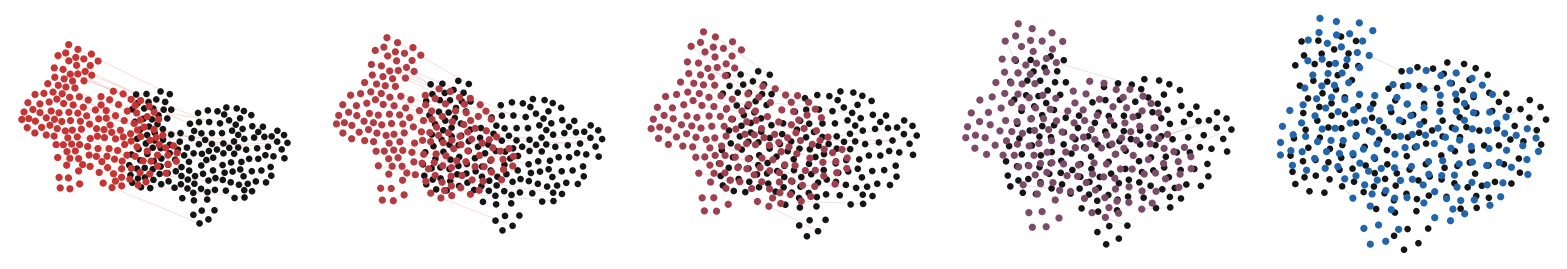

In [9]:
from IPython.display import Image, display
_thumb = FIGROOT / "thumbnails" / "wasserstein-procrustes-rigid-motion.png"
if _thumb.exists():
    display(Image(filename=str(_thumb)))
else:
    print(f"Missing thumbnail: {_thumb}")